In [106]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

In [6]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [69]:
#cases = ["M1_A1_NE","S1_3","R3","R4"]
#projects = ["scan_beta","scan_q","scan_shat"]
cases = ["R4"]
projects = ["scan_beta"]

In [70]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    project_dict[project] = case_dict

Project: scan_beta, Case: R4


In [71]:
tglf_versions = ["TGLF","tglf_v1","tglf_v2"]
name_dict = {
    "TGLF":"Default",
    "tglf_v1": "V1",
    "tglf_v2": "V2",
}
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            print(f"Project: {project}, Case: {case}")
            json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.json"))
            net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.nc"))
            try:
                tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                try:
                    tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                    version_dict[name_dict[version]] = tglf_pyoscan
                except Exception as e:
                    print(f"Error loading gk output for {project}/{case}/{version}: {e}")
                    # try:
                    #     tglf_pyoscan.load_gk_output()
                    #     tglf_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    #     version_dict[version] = tglf_pyoscan
                    # except Exception as e:
                    #     print(f"Error loading gk output without netcdf for {project}/{case}/{version}: {e}")
            except Exception as e:
                print(f"Error loading pyroscan for {project}/{case}/{version}: {e}")
                continue
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4


In [10]:
tglf_versions = ["Default","V1","V2"]

In [101]:
# Plot Eigenfunction Differences between GS2, tglf_default and TGLF_v1, and TGLF_v2

project = "scan_beta"
case = "R4"
ky = 0.5
beta = 0.10
reference_q = 0.036


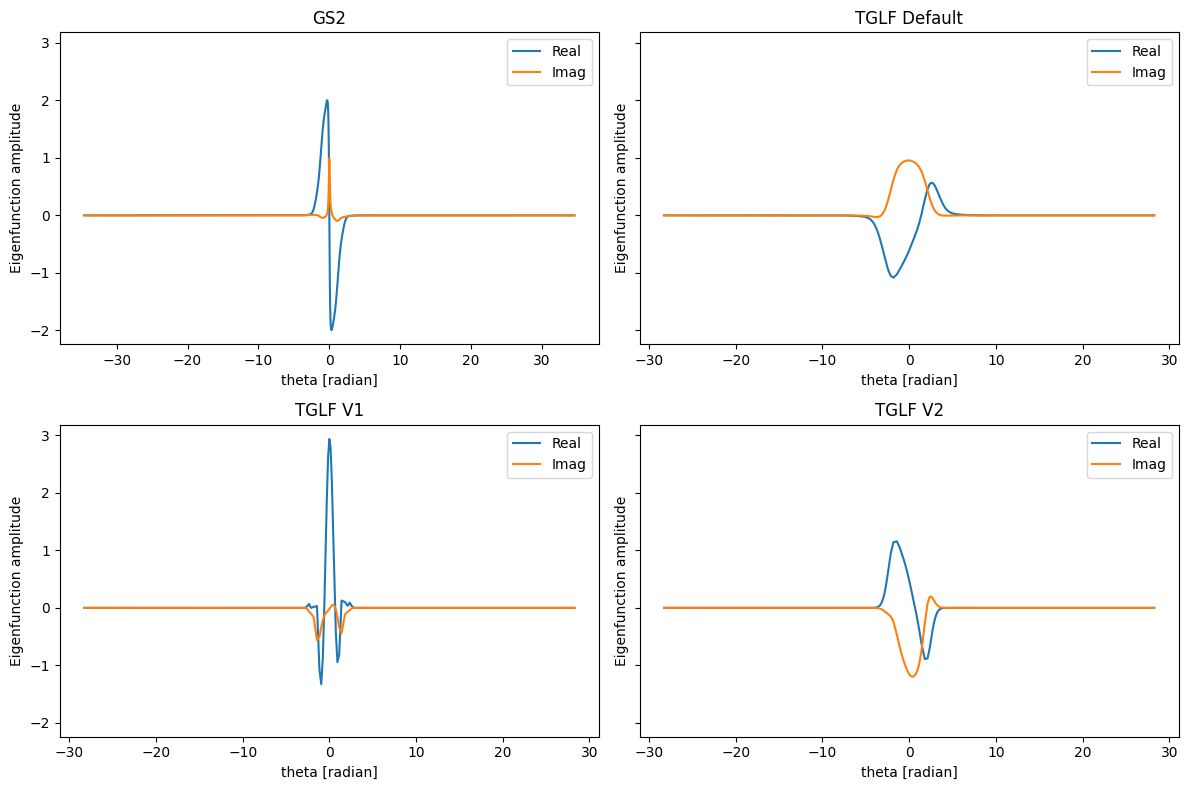

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

labels = ["GS2", "TGLF Default", "TGLF V1", "TGLF V2"]

def get_eig(data, is_gs2=False):
    sel = data.gk_output["eigenfunctions"].sel(ky=ky, method="nearest").sum(dim="field").sel(beta=beta)
    if not is_gs2:
        sel = sel.sel(mode=0)
    return np.real(sel), np.imag(sel)

real_gs2, imag_gs2 = get_eig(project_dict[project][case], is_gs2=True)
real_def, imag_def = get_eig(tglf_project_dict[project][case]["Default"])
real_v1,  imag_v1  = get_eig(tglf_project_dict[project][case]["V1"])
real_v2,  imag_v2  = get_eig(tglf_project_dict[project][case]["V2"])

data_pairs = [
    (real_gs2, imag_gs2),
    (real_def, imag_def),
    (real_v1,  imag_v1),
    (real_v2,  imag_v2),
]

for ax, (real, imag), label in zip(axes.flat, data_pairs, labels):
    real.plot(ax=ax, label="Real")
    imag.plot(ax=ax, label="Imag")
    ax.set_ylabel("Eigenfunction amplitude")
    ax.set_title(label)
    ax.legend()

fig.tight_layout()
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Eigenfunction Comparison— {case}, ky={ky_actual:.3f}, beta = {beta}.png", dpi=300)


In [11]:
# GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")
# models_path = "/home/Felix/Documents/Physics_Work/Project_Codes/GP-MODELS/0.0.3/"  # This is using the 3000 data point model as opposed to the 100000 data point model for testing purposes


# models = [
#     "growth_rate",
#     "mode_frequency_log",
#     "kperp2_phi_log",
#     "kperp2_apa_log",
#     "kperp2_bpar_log",
#     "totIonFlux_log",
#     "totElecFlux_log",
#     "totPartFlux_log",
#     "apa_phi_log",
#     "bpar_phi_log",
# ]

# from pyrokinetics.diagnostics.gs2_gp import gs2_gp

In [12]:
# project = "scan_q"
# case = "S1"

# Gaussian_Model =gs2_gp(pyro=project_dict[project][case], models_path=models_path, models=models)

In [ ]:

# Plot Q scan
project = "scan_q"
case = "S1_3"
ky = 0.3
reference_q = 3.49


for tglf in tglf_versions:
    (tglf_project_dict[project][case][tglf]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
        .plot(label=tglf, marker="o", linestyle="--"))

gs2_growth_rate = (project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate_tolerance = (project_dict[project][case]
    .gk_output["growth_rate_tolerance"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance < 0.3)

# Gaussian_Model = gs2_gp(pyro=project_dict[project][case],
#                        models_path=models_path, models=models)
# gp = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="value")
#     .sel(ky=ky, method="nearest"))
# gp_max = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="max_value")
#     .sel(ky=ky, method="nearest"))
# gp_min = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="min_value")
#     .sel(ky=ky, method="nearest"))

# gp.plot(label="GS2-GP", marker="o", linestyle="--")
# plt.fill_between(gp["q"].values, gp_min.values, gp_max.values, color="blue", alpha=0.2, label="GS2-GP Uncertainty")
gs2_growth_rate.plot(label="GS2", color="black", marker="o")

ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)
plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs q — {case}, ky={ky_actual:.3f}")
#plt.title("")
plt.xlabel("q")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



KeyError: 'scan_q'

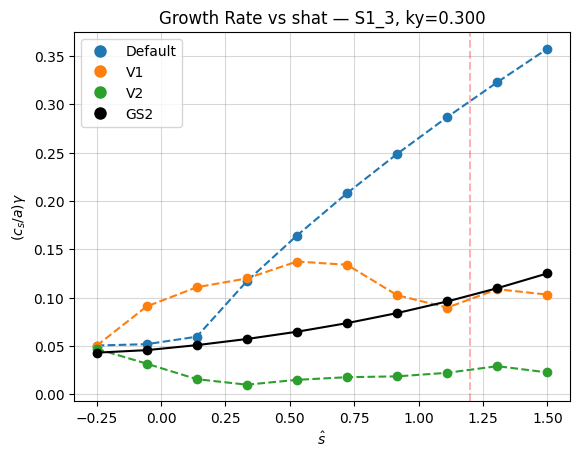

In [ ]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_shat"
case = "S1_3"
ky = 0.3
reference_q = 1.2


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.3)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")


plt.title(f"Growth Rate vs shat — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\hat{s}$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs shat — {case}, ky={ky_actual:.3f}.png", dpi=300)



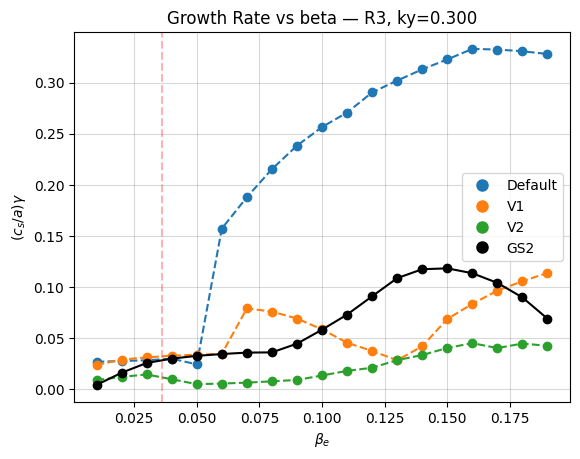

In [ ]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R3"
ky = 0.3
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.1)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

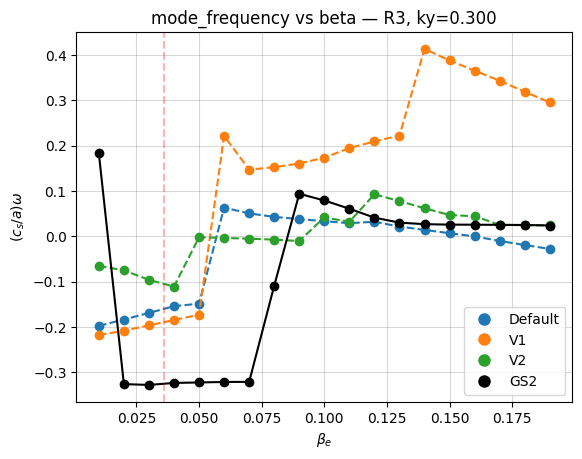

In [ ]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R3"
ky = 0.3
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_mode_frequency = project_dict[project][case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest")
gs2_mode_frequency_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_mode_frequency = gs2_mode_frequency.where(gs2_mode_frequency_tolerance<0.1)
gs2_mode_frequency.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["mode_frequency"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"mode_frequency vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \omega$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/mode_frequency vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

_SCAN_LABELS = {
    "beta": r"$\beta_e$",
    "q": r"$q$",
    "shat": r"$\hat{s}$",
    "ky": r"$k_y$",
}
_FIELD_SYM = {"growth_rate": r"\gamma", "mode_frequency": r"\omega"}


def _difference_grid(gs2_output, tglf_output, field, metric, scan_param, mode):
    """Return (ky, par, diff2d, scan_param) for one GS2/TGLF pair."""
    gr_gs2 = gs2_output[field]
    gr_tglf = tglf_output[field]
    if "mode" in gr_tglf.dims:
        gr_tglf = gr_tglf.sel(mode=mode)

    if scan_param is None:
        other = [d for d in gr_gs2.dims if d != "ky"]
        if len(other) != 1:
            raise ValueError(
                f"Could not auto-detect scan_param from dims {gr_gs2.dims}; "
                "pass scan_param explicitly."
            )
        scan_param = other[0]

    # Align TGLF onto the GS2 grid so the subtraction is well defined
    gr_tglf = gr_tglf.interp(ky=gr_gs2["ky"], **{scan_param: gr_gs2[scan_param]})

    gr_gs2 = gr_gs2.transpose("ky", scan_param)
    gr_tglf = gr_tglf.transpose("ky", scan_param)

    if metric == "absolute":
        diff = gr_tglf.values - gr_gs2.values
    elif metric == "relative":
        diff = (gr_tglf.values - gr_gs2.values) / np.abs(gr_gs2.values)
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    return gr_gs2["ky"].data, gr_gs2[scan_param].data, diff, scan_param


def plot_field_difference(gs2_output, tglf_outputs,
                          field="growth_rate",
                          metric="absolute",
                          scan_param=None,
                          mode=0,
                          vmax=None,
                          vmax_quantile=1.0,
                          cmap="seismic",
                          axes=None,
                          savefig=None):
    """
    Heatmap(s) of GS2-vs-TGLF difference in a linear field over
    (ky, <scan parameter>), one panel per TGLF version with a shared,
    symmetric colour scale.

        plot_field_difference(
            project_dict[project][case].gk_output,
            {v: tglf_project_dict[project][case][v].gk_output
             for v in tglf_versions},
        )

    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth ``.gk_output``.
    tglf_outputs : mapping or sequence
        ``{label: gk_output}`` (or a single gk_output / list of them).
    field : str
        "growth_rate" or "mode_frequency".
    metric : {"absolute", "relative"}
        absolute -> Δ = tglf - gs2;  relative -> Δ / |gs2|.
    scan_param : str or None
        Scan axis name; auto-detected as the non-ky dim if None.
    mode : int
        Mode index selected from each TGLF output.
    vmax : float or None
        Symmetric colour limit. If None it is derived from the data across
        *all* versions (see vmax_quantile).
    vmax_quantile : float in (0, 1]
        Quantile of |Δ| (pooled over every version) used for the auto limit.
        1.0 = exact max; 0.98 clips a few outliers so the bulk has contrast.
    """

    # Normalise input to an ordered {label: output} dict
    if hasattr(tglf_outputs, "items"):
        items = list(tglf_outputs.items())
    elif isinstance(tglf_outputs, (list, tuple)):
        items = [(f"tglf {i}", o) for i, o in enumerate(tglf_outputs)]
    else:
        items = [("tglf", tglf_outputs)]

    # Compute every difference grid once
    grids = []
    for label, out in items:
        ky, par, diff, scan_param = _difference_grid(
            gs2_output, out, field, metric, scan_param, mode
        )
        grids.append((label, ky, par, diff))

    # Shared symmetric colour scale across all versions
    if vmax is None:
        pooled = np.abs(np.concatenate([g[3].ravel() for g in grids]))
        pooled = pooled[np.isfinite(pooled)]
        vmax = (np.quantile(pooled, vmax_quantile) if pooled.size
                else 1.0) or 1.0
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    n = len(grids)
    if axes is None:
        fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 5),
                                 sharey=True, squeeze=False)
        axes = axes[0]
    else:
        axes = np.atleast_1d(axes)
        fig = axes[0].figure

    pcm = None
    for ax, (label, ky, par, diff) in zip(axes, grids):
        ky_grid, par_grid = np.meshgrid(ky, par, indexing="ij")
        pcm = ax.pcolormesh(ky_grid, par_grid, diff,
                            cmap=cmap, norm=norm, shading="auto")
        ax.set_title(label)
        ax.set_xlabel(_SCAN_LABELS.get("ky", "ky"))
    axes[0].set_ylabel(_SCAN_LABELS.get(scan_param, scan_param))

    sym = _FIELD_SYM.get(field, r"x")
    if metric == "absolute":
        clabel = rf"$\Delta {sym}$"
    else:
        clabel = rf"$\Delta {sym} / |{sym}_{{\mathrm{{GS2}}}}|$"
    cbar = fig.colorbar(pcm, ax=list(axes), orientation="horizontal",
                        location="top", fraction=0.05, pad=0.10)
    cbar.set_label(clabel, labelpad=6)
    if savefig is not None:
        os.makedirs(os.path.dirname(savefig), exist_ok=True)
        fig.savefig(savefig, bbox_inches="tight", dpi=150)
    return fig, axes




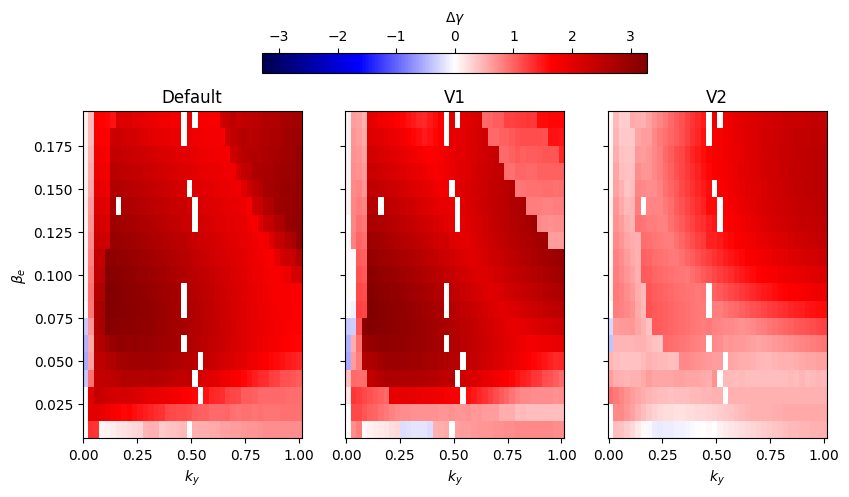

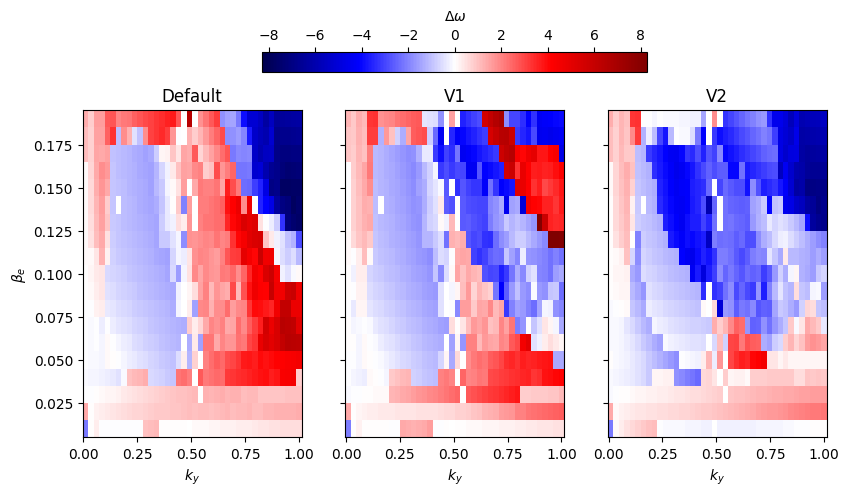

In [ ]:
project, case = "scan_beta", "M1_A1_NE"
gs2 = project_dict[project][case].gk_output
tglfs = {v: tglf_project_dict[project][case][v].gk_output for v in tglf_versions}

for field in ["growth_rate", "mode_frequency"]:
    name = f"Absolute Error Colourmap {field} For {case}"
    location = f"../Plots/{project}/{case}/{name}.png"
    plot_field_difference(gs2, tglfs, field=field, savefig=location)
